## 🏝️ Taylor 2023

**Concepts:** [Warm-starting](../routers.md#warm-starting) · [Crossings & detours](../problem.md#crossings-contours-and-detours) **Advanced API:** [🏝️ Taylor 2023](lo40_example_taylor_2023.ipynb)

This notebook applies _OptiWindNet_ to a large-scale wind farm with 122 turbines and 2 substations, set in a concave area containing an internal obstacle. [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) provides the warm start and [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) with the COIN-OR CBC solver produces the final branched network.

In [1]:
from optiwindnet.api import WindFarmNetwork, EWRouter, MILPRouter, ModelOptions, load_repository

### Load input data

> Note: the [load_repository()](../autoapi/optiwindnet/importer/index.rst#optiwindnet.importer.load_repository) functionality of _OptiWindNet_ is used to load a prebuilt _Networkx.Graph_ of the avaible locations. For more details on this functionality look into the notebook about [🗂️ Locations](hi12_locations.ipynb).

In [2]:
locations = load_repository()

The example location from <https://onlinelibrary.wiley.com/doi/abs/10.1049/rpg2.12593> (Taylor_2023) provides suitable specifications for our purpose; a large wind farm with multiple substations and complex geometry.

In [3]:
wfn = WindFarmNetwork(
    L=locations.taylor_2023,
    cables=[(5, 1800.0), (8, 2200.0)],
)

> Note: To view output plots, trust this notebook first.

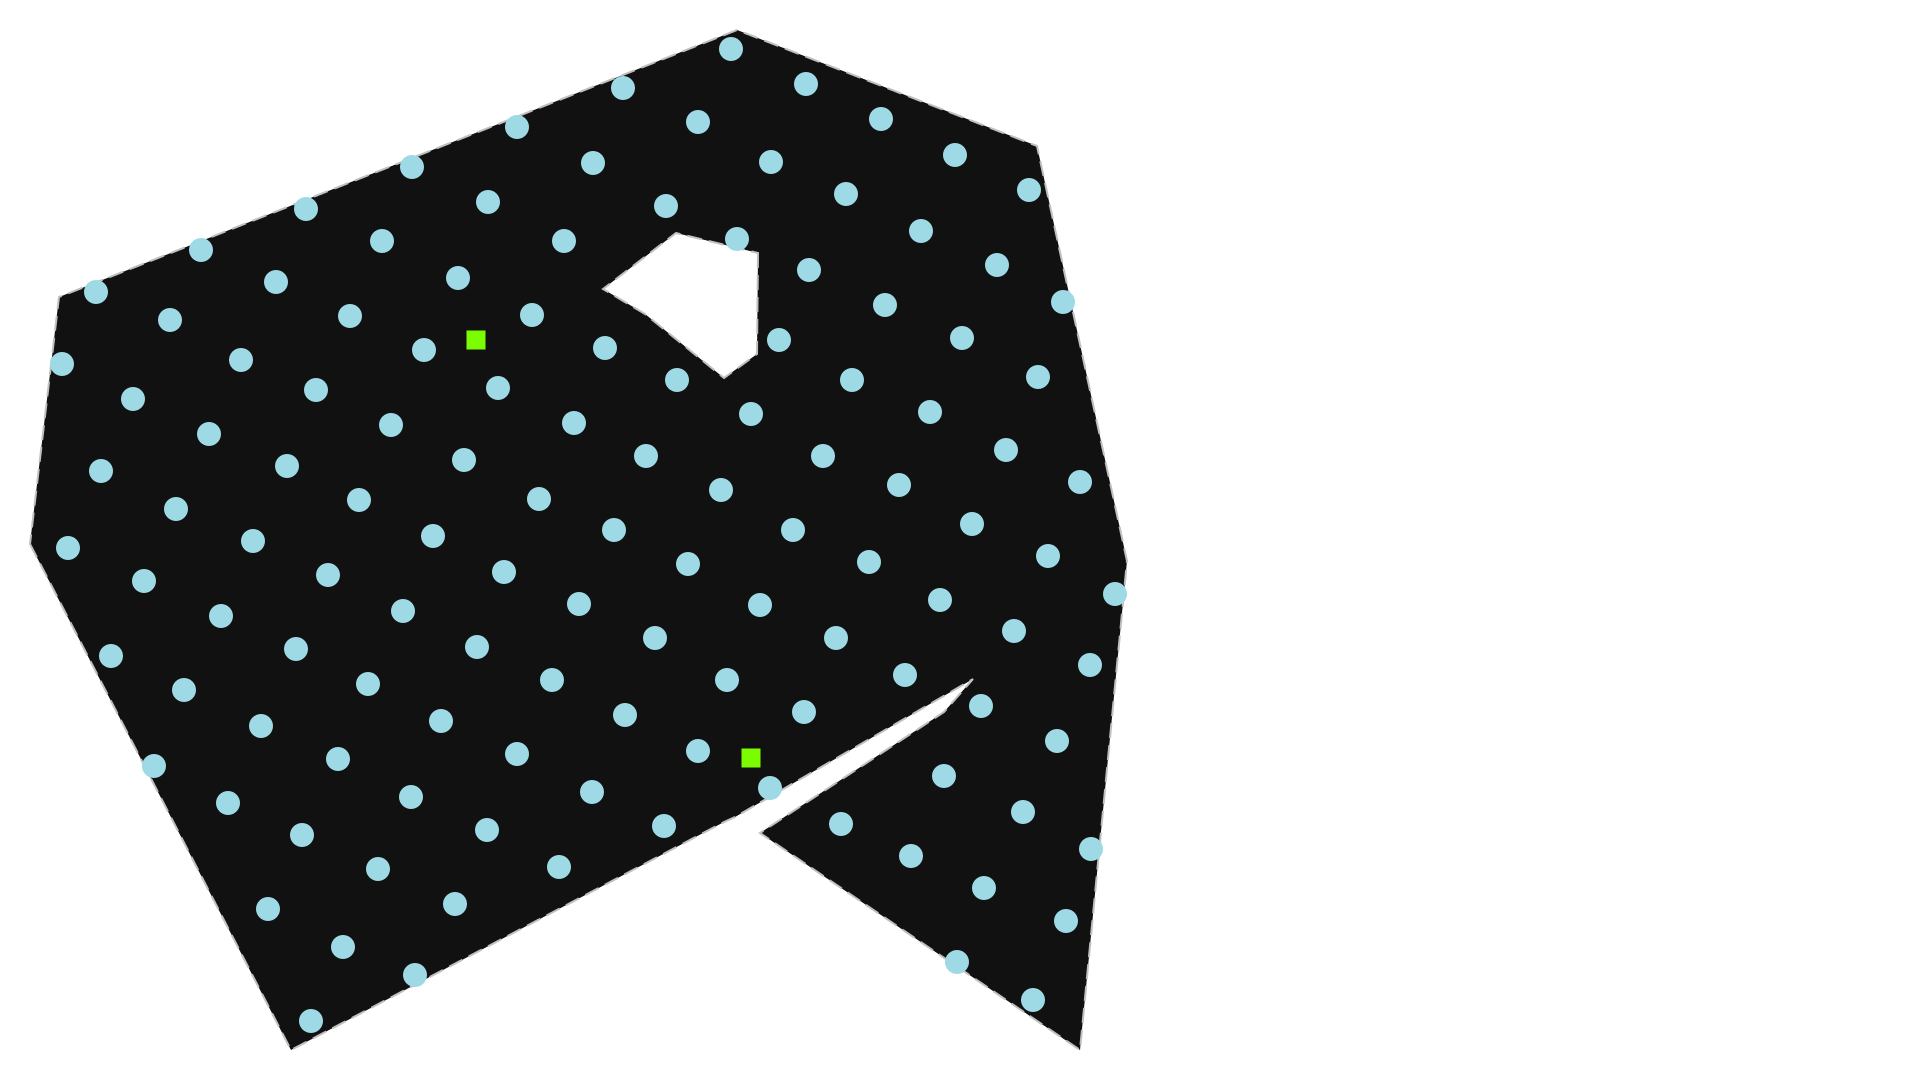

In [4]:
wfn

There are two options for generating an initial solution to warm-start the [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter): the heuristic [EWRouter()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) or the meta-heuristic [HGSRouter()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter). Which of them is eligible depends on the model being started — see [Warm-starting](../routers.md#warm-starting).

### Generate the warm-start solution

To generate a warm-start solution, simply run [wfn.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) with the desired solver e.g.:

```python
wfn.optimize(router=warmstart_router)
```

In this example, we use [EWRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.EWRouter) to warm-start the optimization model. Alternatively, [HGSRouter()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.HGSRouter) can be used for the same purpose.

The resulting solution is stored within the `wfn` object. The next time [wfn.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) is called, the stored solution (`S` which contains _selected-links_) will be reused as a warm start; provided that the solver in [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) supports warm-starting.

In [5]:
warmstart_router = EWRouter()
res_warmstart= wfn.optimize(router=warmstart_router)

In [6]:
wfn.length()

113587.95387324075

#### Visualizing the warm-start solution

`S` can be visualized using [wfn.plot_selected_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_selected_links).

> Check [the plotting tutorial](hi14_plotting.ipynb) for details on the available plots.

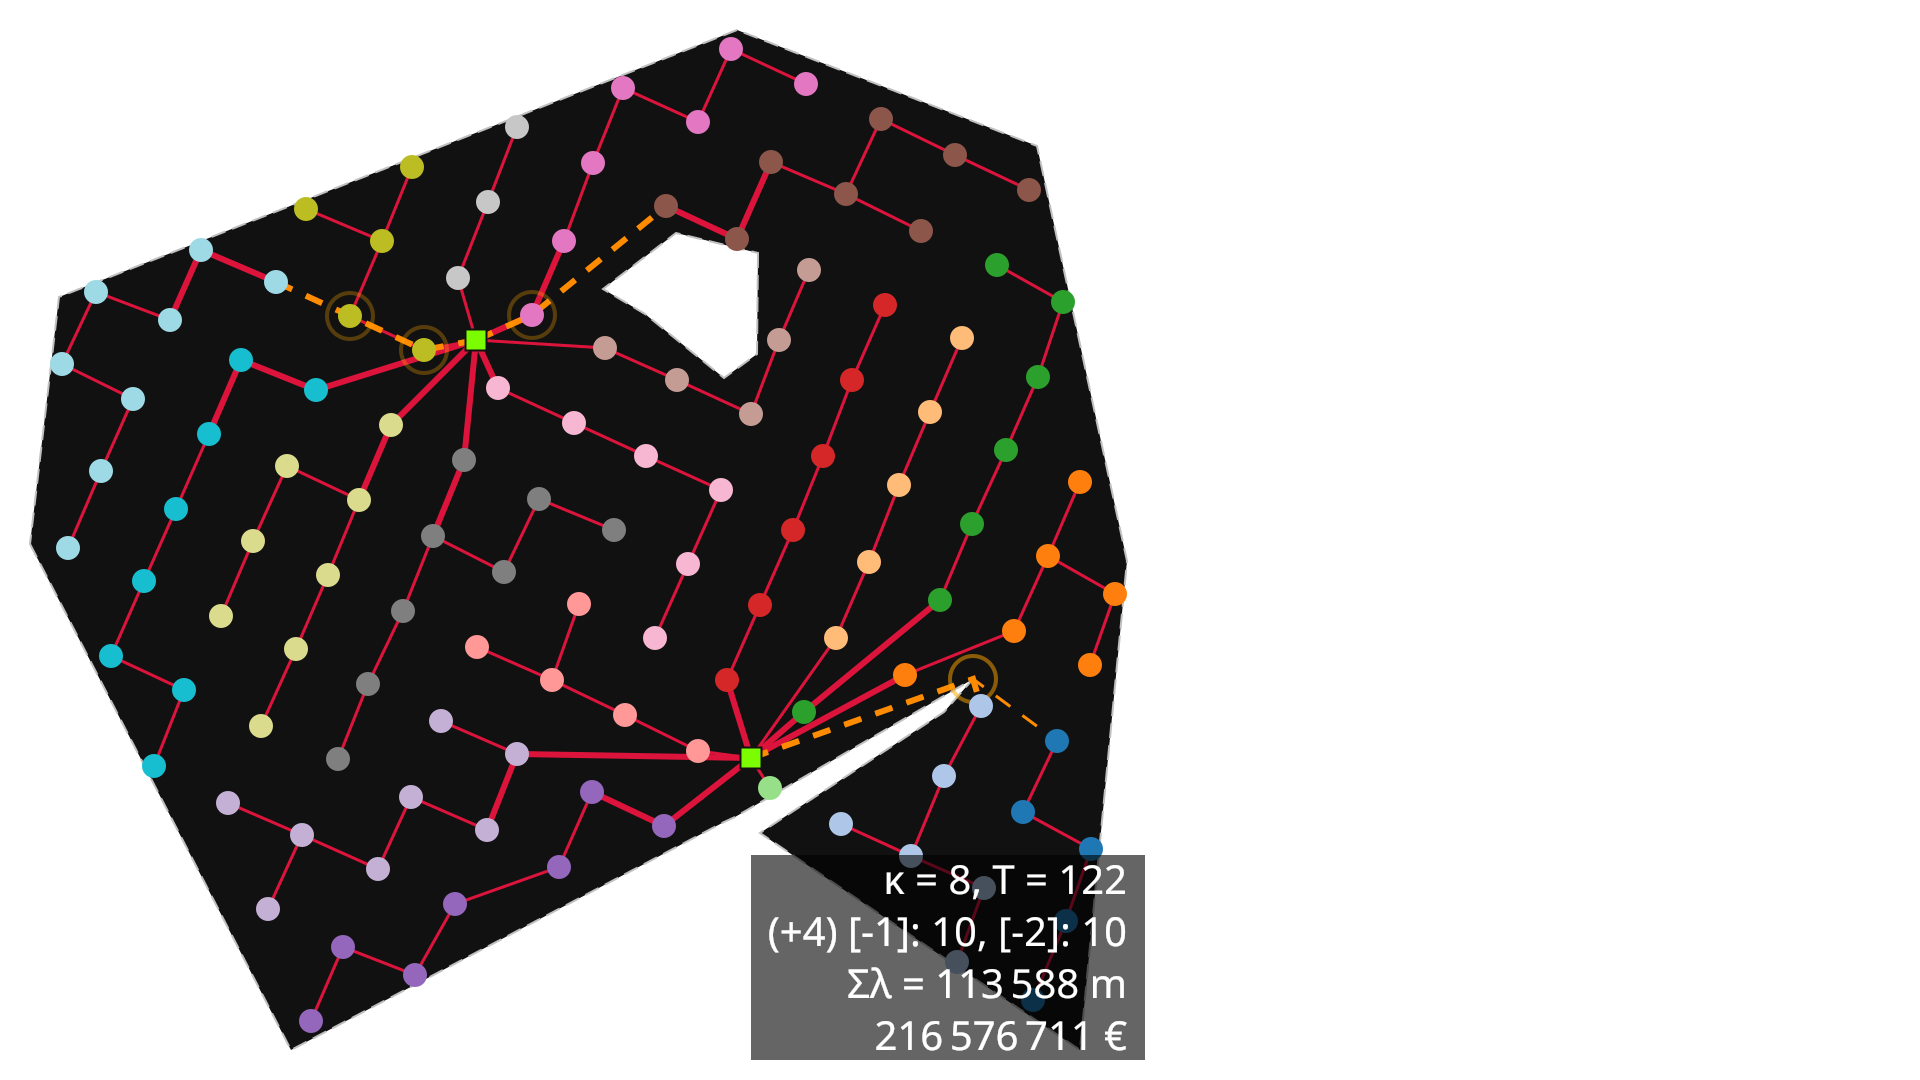

In [7]:
wfn

### MILP Router

Create an instance of [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) and choose COIN-OR Branch and Cut (CBC) as solver.

When initializing a [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) three arguments are required to be given:

- solver name
- time limit
- gap

Solver options, including those set by OptiWindNet as well as additional configurable parameters, can be modified by creating a **dictionary** and passing it to the router. The same approach applies to **model options**. For a detailed explanation about model_options and solver_options of MILP routers see the notebook about [🔧 Options](hi31_options.ipynb).

In [8]:
solver_options=dict( # these are in addition to the default solver.options
    # CLP and CBC have separate random-number generators; seed both. Even
    # then, parallel search is nondeterministic unless limited to one thread.
    randomSeed=1234567,  # CLP: tie-breaking in degenerate LPs
    randomCbcSeed=1234567,  # CBC: heuristics such as Feasibility Pump
)

model_options = ModelOptions(
    topology='branched',
    feeder_limit='unlimited',
    feeder_route='segmented',
)

milp_router = MILPRouter(
    solver_name='cbc',
    time_limit=60,
    mip_gap=0.005,
    solver_options=solver_options,
    model_options=model_options,
)

#### Run optimization with MILP router

In [9]:
# Set logging level to INFO to display messages about solver options
import logging
logging.basicConfig(level=logging.INFO)

# run optimization with the milp router (Set verbose=True to display messages about solver progress)
res = wfn.optimize(router=milp_router, verbose=True)

INFO:optiwindnet.MILP.pyomo:>>> pyomo.cbc solver options <<<
Dins: 'on'
RandomCbcSeed: 1234567
Rens: 'on'
VndVariableNeighborhoodSearch: 'on'
cliqueCuts: 'off'
flowCoverCuts: 'on'
knapsackCuts: 'off'
mixedIntegerRoundingCuts: 'on'
nodeStrategy: 'downFewest'
ratioGap: 0.005
seconds: 60
threads: 8
timeMode: 'elapsed'
zeroHalfCuts: 'off'



Welcome to the CBC MILP Solver 
Version: 2.10.13 
Build Date: Apr  1 2026 

command line - /usr/bin/cbc -threads 8 -timeMode elapsed -nodeStrategy downFewest -Dins on -VndVariableNeighborhoodSearch on -Rens on -mixedIntegerRoundingCuts on -flowCoverCuts on -cliqueCuts off -knapsackCuts off -zeroHalfCuts off -RandomCbcSeed 1234567 -seconds 60 -ratioGap 0.005 -printingOptions all -import /home/masoda/tmp/tmpvke6if6l.pyomo.lp -mipstart /home/masoda/tmp/tmpptd70kky.cbc.soln -stat=1 -solve -solu /home/masoda/tmp/tmpvke6if6l.pyomo.soln (default strategy 1)
threads was changed from 0 to 8
Option for timeMode changed from cpu to elapsed
Option for nodeStrategy changed from fewest to downfewest
Option for Dins changed from off to on
Option for VndVariableNeighborhoodSearch changed from off to on
Option for Rens changed from off to on
Option for mixedIntegerRoundingCuts changed from ifmove to on
Option for flowCoverCuts changed from ifmove to on
Option for cliqueCuts changed from ifmove to off
O

INFO:optiwindnet.MILP.pyomo:>>> Solution <<<
SolutionInfo(runtime=60.28, bound=105397.23, objective=106976.82597848, relgap=0.01476577720484773, termination='maxTimeLimit')



In [10]:
wfn.solution_info()

{'router': 'MILPRouter',
 'capacity': 8,
 'solver_name': 'pyomo.cbc',
 'mip_gap': 0.005,
 'time_limit': 60,
 'topology': <Topology.BRANCHED: 'branched'>,
 'feeder_route': <FeederRoute.SEGMENTED: 'segmented'>,
 'feeder_limit': <FeederLimit.UNLIMITED: 'unlimited'>,
 'balanced': False,
 'runtime': 60.28,
 'bound': 105397.23,
 'objective': 106976.82597848,
 'relgap': 0.01476577720484773,
 'termination': 'maxTimeLimit'}

In [11]:
wfn.G.size(weight='length')

106976.82597847644

In [12]:
wfn.length()

106976.82597847644

A topology-aware [TerseLinks](../autoapi/optiwindnet/terse/index.rst#optiwindnet.terse.TerseLinks) object is returned by [wfn.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize). It behaves like a NumPy array and carries the solution architecture in its [topology](../autoapi/optiwindnet/terse/index.rst#optiwindnet.terse.TerseLinks.topology) attribute. If the result is not assigned to a variable (for example, `res`), it remains available through [wfn.terse_links()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.terse_links).

In [13]:
res

TerseLinks(scope='topology', topology='branched', T=122, R=2, links=122)

#### Plot the optimized network graph

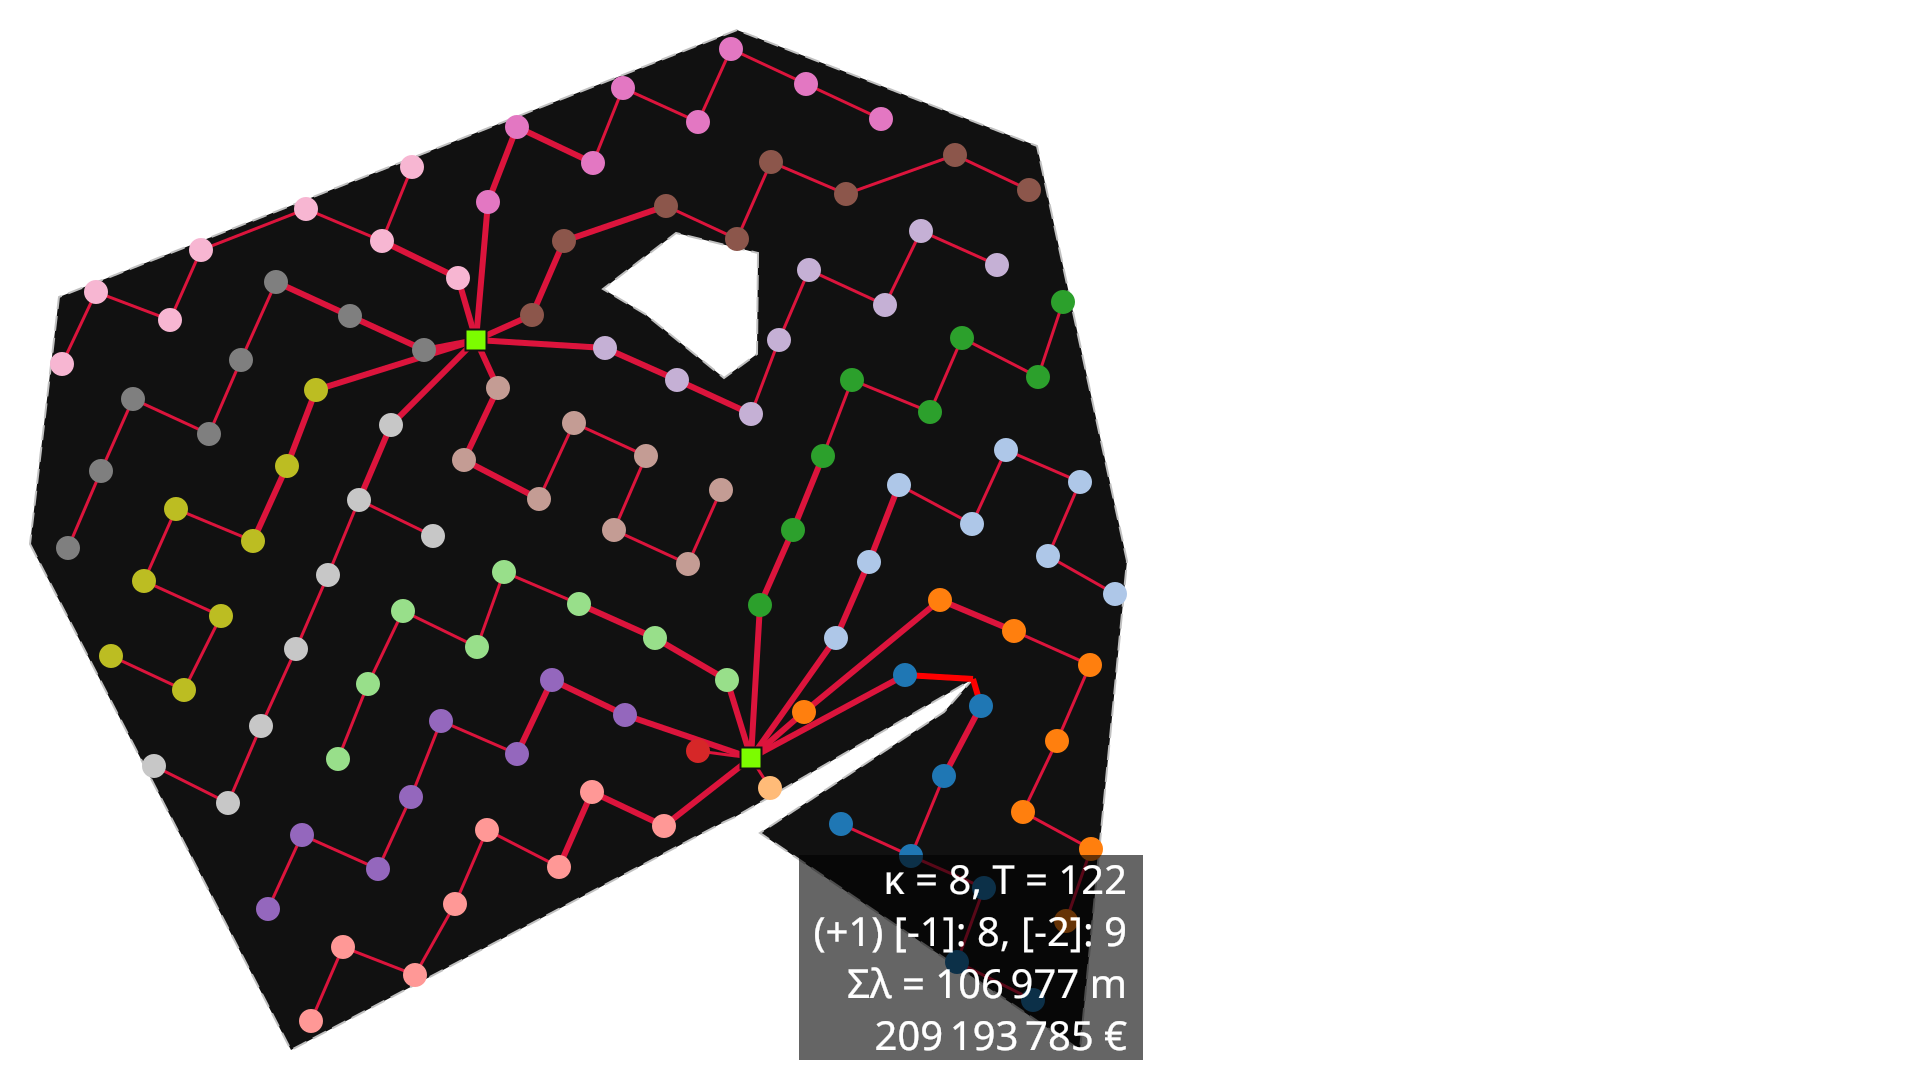

In [14]:
wfn